# 2 — Model

Train Random Forest classifier (backend selection) and regressor (runtime estimation). Compare with baselines. Generate figures for the paper.

**Run after** `0_preprocess.ipynb`.

In [23]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, mean_absolute_error, r2_score,
)

# IEEE-paper PDF quality: vector PDF with embedded TrueType fonts, serif,
# single-column = 3.5 in, double-column = 7.16 in.
matplotlib.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "serif",
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
C = ["#4E79A7", "#F28E2B", "#E15759", "#76B7B2", "#59A14F",
     "#EDC948", "#B07AA1", "#FF9DA7", "#9C755F", "#BAB0AC"]

COL1_W = 3.5    # IEEE single-column width (in)
COL2_W = 7.16   # IEEE double-column width (in)

BASE = Path("/lustre/orion/gen008/proj-shared/qhpc/srikar/qfw_related")
# Save figures locally to MQBac/images/. Copy the ones you want into the
# paper at meta_backend_paper/meta_backend_qfw/images/ manually.
IMG = Path("images")
IMG.mkdir(parents=True, exist_ok=True)

# Load data
best_df = pd.read_csv("final_data/best_backend_df.csv")
est_df  = pd.read_csv("final_data/estimate_runtime_df.csv")
print(f"Classification data: {best_df.shape}")
print(f"Regression data:     {est_df.shape}")
print(f"Backend classes:     {sorted(best_df['best_backend'].dropna().unique())}")


Classification data: (215, 65)
Regression data:     (3500, 80)
Backend classes:     ['ibmq', 'ionq', 'nwqsim', 'qiskitaer', 'tnqvm']


## 1. Backend Selection (Classification)

Predict the best backend (lowest runtime) from circuit features + resource config.

In [24]:
# Drop rows without labels or features
clf_df = best_df.dropna(subset=["best_backend", "depth"]).copy()
print(f"Usable classification rows: {len(clf_df)}")

# Target
y_cls = clf_df["best_backend"]

# Features: drop identifiers, target, and label-leaking columns.
# `sub_backend` is the winning backend's sub-backend → leakage; drop it.
# `n_qubits` duplicates `size`.
drop_cols = ["best_backend", "best_runtime", "benchmark", "sub_backend", "n_qubits"]
X_cls = clf_df.drop(columns=[c for c in drop_cols if c in clf_df.columns])

# ── Pearson r > 0.95 correlation pruning on numeric features (per paper) ──
num_cols_all = X_cls.select_dtypes(exclude=["object"]).columns.tolist()
if len(num_cols_all) > 1:
    corr = X_cls[num_cols_all].corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    redundant = [c for c in upper.columns if (upper[c] > 0.95).any()]
    if redundant:
        print(f"Dropping {len(redundant)} highly-correlated features (r>0.95)")
        X_cls = X_cls.drop(columns=redundant)

cat_cols = X_cls.select_dtypes(include=["object"]).columns.tolist()
num_cols = X_cls.select_dtypes(exclude=["object"]).columns.tolist()

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
    ("num", SimpleImputer(strategy="median"), num_cols),
])

clf_pipe = Pipeline([
    ("pre", preprocessor),
    ("rf", RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)),
])

# Train/test split (stratify if enough samples per class)
min_class = y_cls.value_counts().min()
stratify = y_cls if min_class >= 2 else None
X_tr, X_te, y_tr, y_te = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=stratify
)

clf_pipe.fit(X_tr, y_tr)
y_hat = clf_pipe.predict(X_te)

acc = accuracy_score(y_te, y_hat)
f1 = f1_score(y_te, y_hat, average="macro", zero_division=0)
print(f"\n=== Classification Results ===")
print(f"Accuracy:  {acc:.3f}")
print(f"Macro-F1:  {f1:.3f}")
print(f"\nClassification Report:")
print(classification_report(y_te, y_hat, zero_division=0))

# Cross-validation (if dataset large enough)
if len(clf_df) >= 20:
    cv_scores = cross_val_score(clf_pipe, X_cls, y_cls, cv=min(5, len(clf_df) // 5), scoring="accuracy")
    print(f"CV Accuracy: {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}")

Usable classification rows: 79
Dropping 31 highly-correlated features (r>0.95)


/lustre/orion/gen008/proj-shared/qhpc/srikar/qfw_related/MQBac/mqbacVirtEnv/lib64/python3.11/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['num_control_flow_ops' 'dag_duration' 'qc_duration']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/lustre/orion/gen008/proj-shared/qhpc/srikar/qfw_related/MQBac/mqbacVirtEnv/lib64/python3.11/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['num_control_flow_ops' 'dag_duration' 'qc_duration']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/lustre/orion/gen008/proj-shared/qhpc/srikar/qfw_related/MQBac/mqbacVirtEnv/lib64/python3.11/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/lustre/orion/gen008/proj-shared/qhpc/srikar/q


=== Classification Results ===
Accuracy:  0.875
Macro-F1:  0.603

Classification Report:
              precision    recall  f1-score   support

        ibmq       0.83      1.00      0.91         5
        ionq       0.00      0.00      0.00         1
      nwqsim       0.90      0.90      0.90        10

    accuracy                           0.88        16
   macro avg       0.58      0.63      0.60        16
weighted avg       0.82      0.88      0.85        16



/lustre/orion/gen008/proj-shared/qhpc/srikar/qfw_related/MQBac/mqbacVirtEnv/lib64/python3.11/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['num_control_flow_ops' 'dag_duration' 'qc_duration']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/lustre/orion/gen008/proj-shared/qhpc/srikar/qfw_related/MQBac/mqbacVirtEnv/lib64/python3.11/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['num_control_flow_ops' 'dag_duration' 'qc_duration']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/lustre/orion/gen008/proj-shared/qhpc/srikar/qfw_related/MQBac/mqbacVirtEnv/lib64/python3.11/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['num_control_flow_ops' 'dag_duration' 'qc_duration']. At least one non-missing value is needed for imputati

CV Accuracy: 0.696 +/- 0.161


/lustre/orion/gen008/proj-shared/qhpc/srikar/qfw_related/MQBac/mqbacVirtEnv/lib64/python3.11/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['num_control_flow_ops' 'dag_duration' 'qc_duration']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [25]:
# ── Baselines: Heuristic-based selection (Fig. 1) + always-NWQSim ──
#
# The static "heuristic" baseline is the simulator-selection decision
# tree shown in Fig. 1 (label `fig:sim_heuristics`, citing Alexeev 2024).
# Its branches are, in order:
#     1. <50 qubits      → state-vector family
#     2. depth <100      → tensor-network family
#     3. mostly Clifford → near-Clifford family
#     4. otherwise       → "candidate for quantum advantage" (abstain)
# It picks a *family*, not a concrete implementation, so we score it as
# correct when the true winning backend belongs to the predicted family.

SIM_LABELS    = {"qiskitaer", "nwqsim", "qtensor", "tnqvm"}
FAMILY_SV     = {"qiskitaer", "nwqsim"}      # state-vector
FAMILY_TN     = {"qtensor", "tnqvm"}         # tensor-network
FAMILY_CLIFF  = {"qiskitaer", "nwqsim"}      # stabilizer paths inside SV sims
ABSTAIN       = set()                        # "quantum advantage" branch

def heuristic_family(row):
    """Static simulator selector from Fig. 1. Returns a backend family
    (set of allowed labels) or empty set if the heuristic abstains."""
    nq    = row.get("size", row.get("n_qubits", 0)) or 0
    depth = row.get("depth", 0) or 0
    cliff    = row.get("clifford_count", row.get("num_cliffords", 0)) or 0
    noncliff = row.get("nonclifford_count", row.get("num_non_cliffords", 0)) or 0
    if pd.isna(nq): nq = 0
    if pd.isna(depth): depth = 0
    if pd.isna(cliff): cliff = 0
    if pd.isna(noncliff): noncliff = 0
    total_gates = cliff + noncliff
    cliff_frac = (cliff / total_gates) if total_gates > 0 else 0.0

    # Order matches the flowchart top→bottom.
    if nq < 50:
        return FAMILY_SV
    if depth < 100:
        return FAMILY_TN
    if cliff_frac >= 0.95:
        return FAMILY_CLIFF
    return ABSTAIN  # quantum-advantage regime: heuristic gives up

# Restrict heuristic evaluation to simulator-only test rows (fair).
sim_mask = y_te.isin(SIM_LABELS)
y_te_sim = y_te[sim_mask]
X_te_sim = X_te.loc[sim_mask]

if len(y_te_sim) > 0:
    heur_fam = X_te_sim.apply(heuristic_family, axis=1)
    bl_heur_sim = float(np.mean([truth in fam
                                 for truth, fam in zip(y_te_sim, heur_fam)]))
else:
    bl_heur_sim = float("nan")

# Full-test fairness: the heuristic abstains on hardware backends (no
# rule for IBMQ/IonQ) and on the "quantum advantage" branch. Abstain =
# wrong, so this is the metric directly comparable to MQBac's accuracy.
bl_heur = (bl_heur_sim * len(y_te_sim) / len(y_te)) if len(y_te) else float("nan")

# Need `present` and `most_common` below.
present = set(y_cls.unique())
most_common = y_cls.value_counts().idxmax()

# Always-NWQSim baseline (paper requirement) — full test set.
bl_nwqsim = accuracy_score(y_te, ["nwqsim"] * len(y_te)) if "nwqsim" in present else float("nan")

# Always-most-common baseline (sanity check).
bl_always = accuracy_score(y_te, [most_common] * len(y_te))

# ── Wall-clock speedup of MQBac-recommended vs Always-NWQSim ──
# Build an exact (benchmark, size, backend, n_nodes, n_processes) → mean_ms
# lookup from est_df. Fall back to (benchmark, size, backend) mean if missing.
_rt_cols = [c for c in ["benchmark", "size", "backend", "n_nodes", "n_processes"] if c in est_df.columns]
_target = "runtime_ms" if "runtime_ms" in est_df.columns else "mean_ms"
_rt_full = est_df.dropna(subset=[_target]).groupby(_rt_cols, dropna=False)[_target].mean()
_rt_bsb  = est_df.dropna(subset=[_target]).groupby(["benchmark", "size", "backend"], dropna=False)[_target].mean()

def _lookup_runtime(row, backend):
    key_full = tuple([row.get("benchmark"), row.get("size"), backend] +
                     [row.get(c) for c in ["n_nodes", "n_processes"] if c in _rt_cols])
    if key_full in _rt_full.index:
        return float(_rt_full.loc[key_full])
    key_bsb = (row.get("benchmark"), row.get("size"), backend)
    if key_bsb in _rt_bsb.index:
        return float(_rt_bsb.loc[key_bsb])
    return float("nan")

clf_te_idx = X_te.index
test_rows = clf_df.loc[clf_te_idx]
mqbac_pred = clf_pipe.predict(X_te)

rt_mqbac = np.array([_lookup_runtime(r, p) for (_, r), p in zip(test_rows.iterrows(), mqbac_pred)])
rt_nwq   = np.array([_lookup_runtime(r, "nwqsim") for _, r in test_rows.iterrows()])
rt_oracle = test_rows["best_runtime"].to_numpy(dtype=float)

valid = np.isfinite(rt_mqbac) & np.isfinite(rt_nwq) & (rt_mqbac > 0)
speedup_vs_nwqsim = float(np.nanmean(rt_nwq[valid] / rt_mqbac[valid])) if valid.any() else float("nan")
oracle_speedup    = float(np.nanmean(rt_nwq[valid] / np.maximum(rt_oracle[valid], 1e-9))) if valid.any() else float("nan")

print(f"\n=== Baseline Comparison ===")
print(f"MQBac RF accuracy:                 {acc:.3f}")
print(f"Heuristic (sim-only, family-aware): {bl_heur_sim:.3f}  (n={len(y_te_sim)})")
print(f"Heuristic (full test, abstain=wrong): {bl_heur:.3f}  ({len(y_te_sim)}/{len(y_te)} covered)")
print(f"Always-NWQSim accuracy:            {bl_nwqsim:.3f}")
print(f"Always-{most_common} (most common):   {bl_always:.3f}")
print(f"Mean MQBac speedup vs NWQSim:      {speedup_vs_nwqsim:.2f}x   (oracle: {oracle_speedup:.2f}x)")
print(f"  (lookup coverage: {valid.sum()}/{len(valid)} test rows)")



=== Baseline Comparison ===
MQBac RF accuracy:                 0.875
Heuristic (sim-only, family-aware): 1.000  (n=10)
Heuristic (full test, abstain=wrong): 0.625  (10/16 covered)
Always-NWQSim accuracy:            0.625
Always-nwqsim (most common):   0.625
Mean MQBac speedup vs NWQSim:      4.27x   (oracle: 4.70x)
  (lookup coverage: 15/16 test rows)


/lustre/orion/gen008/proj-shared/qhpc/srikar/qfw_related/MQBac/mqbacVirtEnv/lib64/python3.11/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['num_control_flow_ops' 'dag_duration' 'qc_duration']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


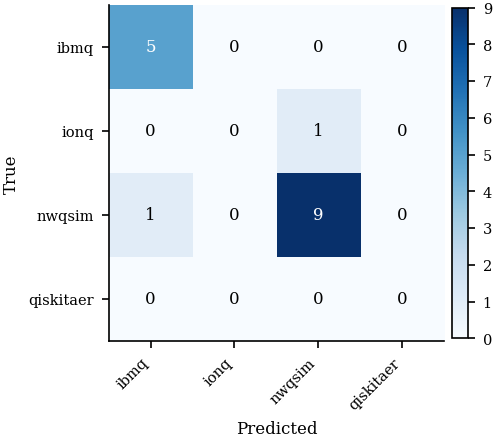

In [26]:
# Confusion matrix (single-column paper figure)
labels = sorted(y_cls.unique())
cm = confusion_matrix(y_te, y_hat, labels=labels)

fig, ax = plt.subplots(figsize=(COL1_W, COL1_W * 0.95))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
plt.tight_layout()
fig.savefig(IMG / "mqbac_confusion_matrix.pdf")
plt.show()


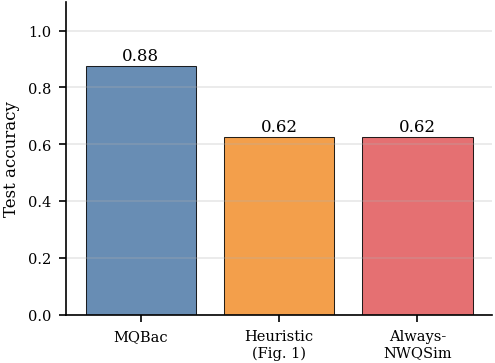

In [27]:
# Baseline comparison: MQBac vs Heuristic (Fig. 1, full-test, abstain=wrong)
# vs Always-NWQSim. `most_common` is dropped when it equals NWQSim to avoid
# duplicate bars.
methods = ["MQBac", "Heuristic\n(Fig.\u00a01)", "Always-\nNWQSim"]
accs    = [acc, bl_heur, bl_nwqsim]
bar_colors = [C[0], C[1], C[2]]
if most_common != "nwqsim":
    methods.append(f"Always-\n{most_common}")
    accs.append(bl_always)
    bar_colors.append(C[3])

fig, ax = plt.subplots(figsize=(COL1_W, COL1_W * 0.75))
bars = ax.bar(methods, accs, color=bar_colors, edgecolor="black",
              linewidth=0.5, alpha=0.85)
for bar, v in zip(bars, accs):
    if isinstance(v, float) and (v != v):
        continue
    ax.text(bar.get_x() + bar.get_width() / 2,
            v + 0.02 if v > 0.02 else 0.04,
            f"{v:.2f}", ha="center")
ax.set_ylim(0, 1.1)
ax.set_ylabel("Test accuracy")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
fig.savefig(IMG / "mqbac_baseline_comparison.pdf")
plt.show()


## 2. Runtime Estimation (Regression)

Predict `mean_ms` from circuit features + backend + resource config.

In [28]:
# Per the paper, the regressor predicts mean wall-clock time (`mean_ms`)
# per workload tuple. Aggregate per-sample timings to a per-tuple mean
# before training so target matches paper.
target_col = "runtime_ms" if "runtime_ms" in est_df.columns else "mean_ms"

reg_df = est_df.dropna(subset=[target_col]).copy()
reg_df = reg_df.dropna(subset=["depth"])

GROUP_KEYS = ["benchmark", "size", "backend", "sub_backend",
              "device", "run_mode", "n_nodes", "n_processes"]
group_keys = [c for c in GROUP_KEYS if c in reg_df.columns]

# Numeric features (mean) + categoricals (first) collapsed per group.
num_feat_cols = [c for c in reg_df.columns
                 if c not in group_keys + [target_col, "std_ms"]
                 and pd.api.types.is_numeric_dtype(reg_df[c])]
agg_dict = {target_col: "mean", **{c: "mean" for c in num_feat_cols}}
reg_mean_df = (
    reg_df.groupby(group_keys, dropna=False)
          .agg(agg_dict)
          .reset_index()
          .rename(columns={target_col: "mean_ms"})
)
print(f"Per-sample regression rows: {len(reg_df)}")
print(f"Aggregated to mean_ms per group: {len(reg_mean_df)}")

y_reg = reg_mean_df["mean_ms"].values

drop_cols = ["mean_ms", "std_ms", "n_qubits", "benchmark"]
X_reg = reg_mean_df.drop(columns=[c for c in drop_cols if c in reg_mean_df.columns])

# ── Pearson r > 0.95 correlation pruning on numeric features (per paper) ──
num_cols_all = X_reg.select_dtypes(exclude=["object"]).columns.tolist()
if len(num_cols_all) > 1:
    corr = X_reg[num_cols_all].corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    redundant = [c for c in upper.columns if (upper[c] > 0.95).any()]
    if redundant:
        print(f"Dropping {len(redundant)} highly-correlated regression features (r>0.95)")
        X_reg = X_reg.drop(columns=redundant)

cat_cols_r = X_reg.select_dtypes(include=["object"]).columns.tolist()
num_cols_r = X_reg.select_dtypes(exclude=["object"]).columns.tolist()

pre_r = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols_r),
    ("num", SimpleImputer(strategy="median"), num_cols_r),
])

reg_pipe = Pipeline([
    ("pre", pre_r),
    ("rf", RandomForestRegressor(n_estimators=400, random_state=42, n_jobs=-1)),
])

Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

reg_pipe.fit(Xr_tr, yr_tr)
yr_hat = reg_pipe.predict(Xr_te)

mae = mean_absolute_error(yr_te, yr_hat)
rmse = np.sqrt(((yr_te - yr_hat) ** 2).mean())
r2 = r2_score(yr_te, yr_hat)

print(f"\n=== Regression Results ===")
print(f"Target: mean_ms (per (benchmark,size,backend,...) tuple)")
print(f"MAE:   {mae:.2f} ms")
print(f"RMSE:  {rmse:.2f} ms")
print(f"R²:    {r2:.3f}")

Per-sample regression rows: 1849
Aggregated to mean_ms per group: 291
Dropping 34 highly-correlated regression features (r>0.95)


/tmp/ipykernel_1805789/1484419522.py:42: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols_r = X_reg.select_dtypes(include=["object"]).columns.tolist()
/lustre/orion/gen008/proj-shared/qhpc/srikar/qfw_related/MQBac/mqbacVirtEnv/lib64/python3.11/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['num_control_flow_ops' 'dag_duration' 'qc_duration']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(



=== Regression Results ===
Target: mean_ms (per (benchmark,size,backend,...) tuple)
MAE:   20181.52 ms
RMSE:  135273.69 ms
R²:    0.827


/lustre/orion/gen008/proj-shared/qhpc/srikar/qfw_related/MQBac/mqbacVirtEnv/lib64/python3.11/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['num_control_flow_ops' 'dag_duration' 'qc_duration']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


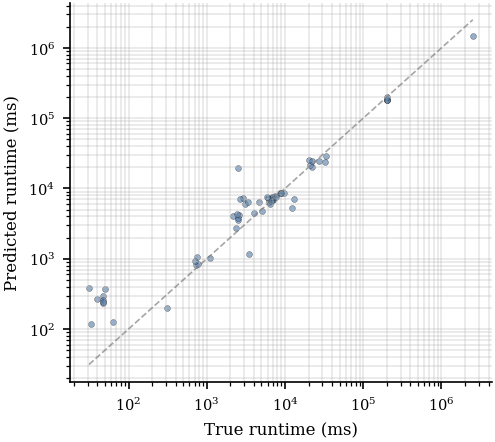

In [29]:
# Regression scatter (single-column paper figure, log-log handles huge dynamic range).
fig, ax = plt.subplots(figsize=(COL1_W, COL1_W * 0.9))
ax.scatter(yr_te, yr_hat, s=8, alpha=0.6, color=C[0],
           edgecolors="black", linewidths=0.2)
_lo = max(min(yr_te.min(), yr_hat.min()), 1e-3)
_hi = max(yr_te.max(), yr_hat.max())
ax.plot([_lo, _hi], [_lo, _hi], "--", color="gray", linewidth=0.8, alpha=0.7)
if _hi / max(_lo, 1e-9) > 1e2:
    ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("True runtime (ms)")
ax.set_ylabel("Predicted runtime (ms)")
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
fig.savefig(IMG / "mqbac_regression_scatter.pdf")
plt.show()


## 3. Feature Importance

Top-15 Gini importance from both the classifier and regressor.

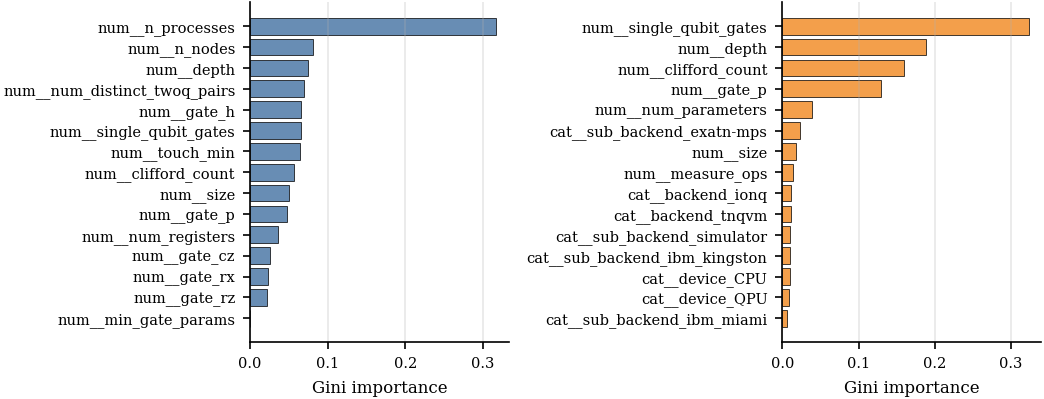

In [30]:
# Top-15 feature importance (double-column paper figure: classifier + regressor).
fig, axes = plt.subplots(1, 2, figsize=(COL2_W, COL2_W * 0.40))

# ── Classifier ──
rf_clf = clf_pipe.named_steps["rf"]
pre_clf = clf_pipe.named_steps["pre"]
try:
    feat_names_clf = pre_clf.get_feature_names_out()
except AttributeError:
    feat_names_clf = [f"f{i}" for i in range(len(rf_clf.feature_importances_))]
imp_clf = rf_clf.feature_importances_
idx_clf = np.argsort(imp_clf)[::-1][:15]

ax = axes[0]
ax.barh(range(15), imp_clf[idx_clf][::-1], color=C[0], edgecolor="black",
        linewidth=0.4, alpha=0.85)
ax.set_yticks(range(15))
ax.set_yticklabels([feat_names_clf[i] for i in idx_clf][::-1])
ax.set_xlabel("Gini importance")
ax.grid(True, axis="x", alpha=0.3)

# ── Regressor ──
rf_reg = reg_pipe.named_steps["rf"]
pre_reg = reg_pipe.named_steps["pre"]
try:
    feat_names_reg = pre_reg.get_feature_names_out()
except AttributeError:
    feat_names_reg = [f"f{i}" for i in range(len(rf_reg.feature_importances_))]
imp_reg = rf_reg.feature_importances_
idx_reg = np.argsort(imp_reg)[::-1][:15]

ax = axes[1]
ax.barh(range(15), imp_reg[idx_reg][::-1], color=C[1], edgecolor="black",
        linewidth=0.4, alpha=0.85)
ax.set_yticks(range(15))
ax.set_yticklabels([feat_names_reg[i] for i in idx_reg][::-1])
ax.set_xlabel("Gini importance")
ax.grid(True, axis="x", alpha=0.3)

plt.tight_layout()
fig.savefig(IMG / "mqbac_feature_importance.pdf")

plt.show()

## 4. Hidden Performance Crossovers

The abstract claims meta-backend benchmarking *uncovers crossovers
opaque to traditional benchmarking*. This figure shows mean wall-clock
runtime vs qubit count, one curve per backend, faceted by benchmark.
Stars mark the winning backend at each qubit size — when stars switch
backends as qubits grow, that is a crossover.


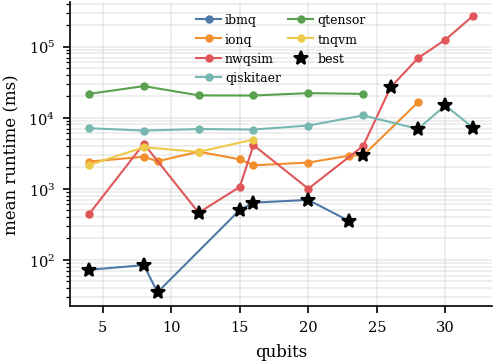

Saved images/mqbac_backend_crossovers_ghz.pdf


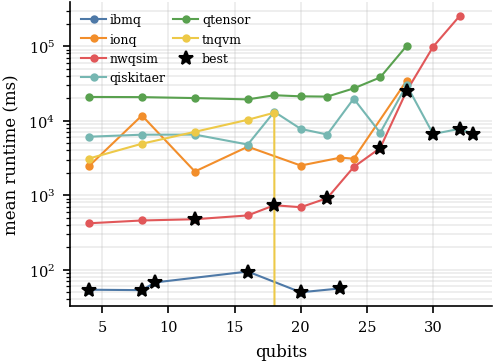

Saved images/mqbac_backend_crossovers_tfim.pdf


In [34]:
# Backend crossover figures (paper headline: "hidden crossovers").
# One single-column figure per benchmark; only GHZ and TFIM are kept.
_t = "runtime_ms" if "runtime_ms" in est_df.columns else "mean_ms"
_xover = (
    est_df.dropna(subset=[_t, "benchmark", "size", "backend"])
          .groupby(["benchmark", "size", "backend"], dropna=False)[_t]
          .mean()
          .reset_index()
)

_bench_map = {b.lower(): b for b in _xover["benchmark"].dropna().unique()}
_benches = [_bench_map[k] for k in ["ghz", "tfim"] if k in _bench_map]

backend_order = sorted(_xover["backend"].unique())
backend_color = {b: C[i % len(C)] for i, b in enumerate(backend_order)}

for bench in _benches:
    sub = _xover[_xover["benchmark"] == bench]
    if sub["backend"].nunique() < 2:
        print(f"[skip] {bench}: only one backend; no crossover possible.")
        continue

    fig, ax = plt.subplots(figsize=(COL1_W, COL1_W * 0.75))
    for be, g in sub.groupby("backend"):
        g = g.sort_values("size")
        ax.plot(g["size"], g[_t], "-o",
                color=backend_color[be], markersize=3,
                linewidth=1.0, label=be)
    winners = sub.loc[sub.groupby("size")[_t].idxmin()]
    ax.plot(winners["size"], winners[_t], "*",
            color="black", markersize=7, zorder=5, label="best")

    ax.set_yscale("log")
    ax.set_xlabel("qubits")
    ax.set_ylabel("mean runtime (ms)")
    ax.grid(True, which="both", alpha=0.25)
    ax.legend(frameon=False, fontsize=6, ncol=2,
              handletextpad=0.3, columnspacing=0.6, loc="best")
    plt.tight_layout()
    out = IMG / f"mqbac_backend_crossovers_{bench.lower()}.pdf"
    fig.savefig(out)
    plt.show()
    print(f"Saved {out}")


## 5. Summary for Paper

Numbers needed for Section 6 of `meta_backend_paper`.


In [32]:
print("=" * 60)
print("  NUMBERS FOR THE PAPER  (Section 6)")
print("=" * 60)

print(f"\n[Classification]")
print(f"  Accuracy:                            {acc:.3f}")
print(f"  Macro-F1:                            {f1:.3f}")
print(f"  Heuristic (Fig. 1, sim-only):        {bl_heur_sim:.3f}")
print(f"  Heuristic (Fig. 1, full test):       {bl_heur:.3f}")
print(f"  Always-NWQSim:                       {bl_nwqsim:.3f}")
print(f"  Always-{most_common} (most-common):     {bl_always:.3f}")
print(f"  Mean speedup vs Always-NWQSim:       {speedup_vs_nwqsim:.2f}x")

print(f"\n[Regression]  (target = mean_ms per workload tuple)")
print(f"  MAE:   {mae:.2f} ms")
print(f"  RMSE:  {rmse:.2f} ms")
print(f"  R²:    {r2:.3f}")

print(f"\n[Feature Importance — Classifier top 5]")
for rank, i in enumerate(idx_clf[:5], 1):
    print(f"  {rank}. {feat_names_clf[i]:30s}  {imp_clf[i]:.4f}")

print(f"\n[Feature Importance — Regressor top 5]")
for rank, i in enumerate(idx_reg[:5], 1):
    print(f"  {rank}. {feat_names_reg[i]:30s}  {imp_reg[i]:.4f}")


  NUMBERS FOR THE PAPER  (Section 6)

[Classification]
  Accuracy:                            0.875
  Macro-F1:                            0.603
  Heuristic (Fig. 1, sim-only):        1.000
  Heuristic (Fig. 1, full test):       0.625
  Always-NWQSim:                       0.625
  Always-nwqsim (most-common):     0.625
  Mean speedup vs Always-NWQSim:       4.27x

[Regression]  (target = mean_ms per workload tuple)
  MAE:   20181.52 ms
  RMSE:  135273.69 ms
  R²:    0.827

[Feature Importance — Classifier top 5]
  1. num__n_processes                0.3171
  2. num__n_nodes                    0.0814
  3. num__depth                      0.0747
  4. num__num_distinct_twoq_pairs    0.0695
  5. num__gate_h                     0.0663

[Feature Importance — Regressor top 5]
  1. num__single_qubit_gates         0.3230
  2. num__depth                      0.1884
  3. num__clifford_count             0.1598
  4. num__gate_p                     0.1300
  5. num__num_parameters             0.0388
